<a href="https://colab.research.google.com/github/lukasakar19-byte/Jaringan-Saraf-Tiruan/blob/main/Projek_JST_Lukas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projek JST

## Flowchart

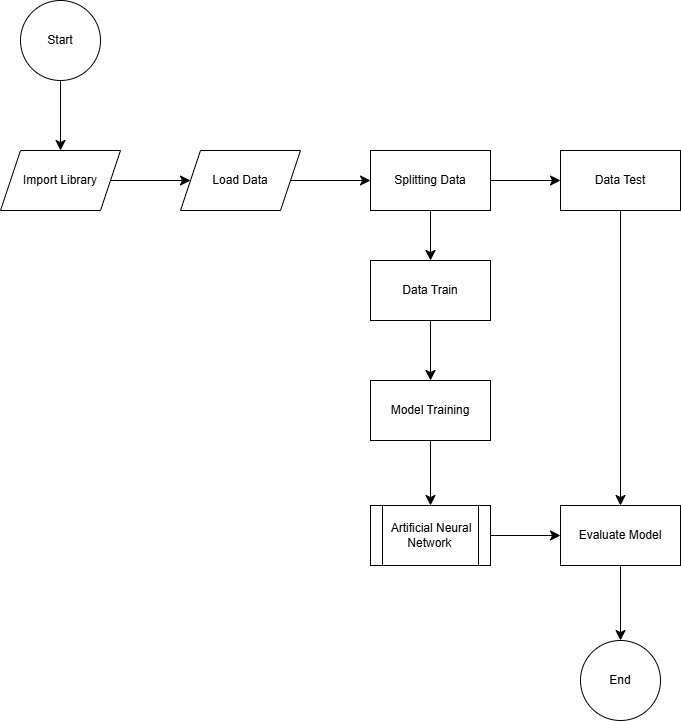

## Generate Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from google.colab import drive
drive.mount('/content/gdrive')
data = pd.read_csv("/content/gdrive/My Drive/Data/credit_data_clean.csv")
data.info()

X = data.drop("Bad_Risk", axis=1)
y = data["Bad_Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 522 entries, 0 to 521
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Age                          522 non-null    float64
 1   Credit amount                522 non-null    float64
 2   Duration                     522 non-null    float64
 3   Sex_female                   522 non-null    bool   
 4   Sex_male                     522 non-null    bool   
 5   Housing_free                 522 non-null    bool   
 6   Housing_own                  522 non-null    bool   
 7   Housing_rent                 522 non-null    bool   
 8   Purpose_business             522 non-null    bool   
 9   Purpose_car                  522 non-null    bool   
 10  Purpose_domestic appliances  522 non-null    bool   
 11  Purpo

Variabel terikat dalam kode tersebut adalah Bad_Risk, yang disimpan dalam variabel y. Variabel ini merupakan target yang ingin diprediksi oleh model Artificial Neural Network (ANN), yaitu status risiko kredit nasabah.

In [19]:
data.head()

,Age,Credit amount,Duration,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Savings_Acc,Checking_Acc,Job_Skill,Bad_Risk
0,-1.094447,0.913171,2.139356,True,False,False,True,False,False,False,False,False,False,True,False,False,0,1,2,1
1,0.858575,1.573037,1.657897,False,True,True,False,False,False,False,False,False,True,False,False,False,0,0,2,0
2,1.537887,0.543768,0.213521,False,True,True,False,False,False,True,False,False,False,False,False,False,0,0,2,1
3,0.009435,1.253868,1.176438,False,True,False,False,True,False,True,False,False,False,False,False,False,0,1,3,0
4,-0.584963,0.668155,0.694979,False,True,False,True,False,False,True,False,False,False,False,False,False,0,1,3,1


In [20]:
data.tail()

,Age,Credit amount,Duration,Sex_female,Sex_male,Housing_free,Housing_own,Housing_rent,Purpose_business,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others,Savings_Acc,Checking_Acc,Job_Skill,Bad_Risk
517,1.113317,-0.524799,0.213521,False,True,False,True,False,False,False,False,False,False,True,False,False,0,1,1,0
518,-0.415135,0.232459,1.176438,False,True,False,True,False,False,False,False,False,True,False,False,False,0,0,3,0
519,0.434005,0.197603,0.694979,False,True,False,True,False,False,True,False,False,False,False,False,False,0,0,3,0
520,-1.009533,-0.489943,1.898626,False,True,True,False,False,False,False,False,False,False,True,False,False,0,0,2,1
521,-0.669877,0.443302,1.898626,False,True,False,True,False,False,True,False,False,False,False,False,False,1,1,2,0


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

## Model

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Fungsi untuk membuat model baru (reset setiap run)
def create_model():
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
# Kombinasi parameter
configs = [
    (5, 16),
    (10, 16),
    (5, 32),
    (10, 32)
]
histories = {}
trained_models = {} # Initialize a dictionary to store trained models
for epochs, batch_size in configs:
    print(f"\nTraining dengan epochs={epochs}, batch_size={batch_size}")

    model = create_model()  # reset model
    key = f"epochs_{epochs}_batch_{batch_size}"
    trained_models[key] = model # Store the trained model in the dictionary

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=1
    )
    histories[key] = history
print("\nSemua kombinasi training selesai. History tersimpan di 'histories'.")
print("Semua model terlatih tersimpan di 'trained_models'.")


Training dengan epochs=5, batch_size=16
Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5651 - loss: 0.7024 - val_accuracy: 0.6164 - val_loss: 0.6510
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6336 - loss: 0.6476 - val_accuracy: 0.6575 - val_loss: 0.6334
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6541 - loss: 0.6150 - val_accuracy: 0.6438 - val_loss: 0.6236
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6918 - loss: 0.5882 - val_accuracy: 0.6301 - val_loss: 0.6168
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7123 - loss: 0.5668 - val_accuracy: 0.6301 - val_loss: 0.6148

Training dengan epochs=10, batch_size=16
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5240 - loss: 0.7581 - val_accuracy: 0.5753 - val_loss: 0.7032
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5753 - loss: 0.6719 - val_accuracy: 0.6164 - val_loss: 0.6795
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 

## Prediksi Model

In [23]:
for key, model in trained_models.items():
    print(f"\nPrediksi untuk model: {key}")

    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    print("First 5 predicted probabilities:")
    print(y_pred_proba[:5].flatten())

    print("First 5 predicted classes:")
    print(y_pred_classes[:5].flatten())


Prediksi untuk model: epochs_5_batch_16
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
First 5 predicted probabilities:
[0.44255596 0.5672823  0.79875535 0.3072916  0.12074586]
First 5 predicted classes:
[0 1 1 0 0]

Prediksi untuk model: epochs_10_batch_16
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
First 5 predicted probabilities:
[0.45883545 0.6219751  0.884196   0.14640117 0.02147364]
First 5 predicted classes:
[0 1 1 0 0]

Prediksi untuk model: epochs_5_batch_32
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
First 5 predicted probabilities:
[0.41434738 0.5792477  0.6697747  0.553812   0.38839155]
First 5 predicted classes:
[0 1 1 1 0]

Prediksi untuk model: epochs_10_batch_32
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
First 5 predicted probabilities:
[0.4094301  0.5554079  0.794275   0.27288112 0.03776516]
First 5 predicted classes:
[0 1 1 0 0]


## Evaluasi Model

In [24]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

for key, model in trained_models.items():
    print(f"\n=== Evaluasi untuk {key} ===")

    # Prediksi
    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_classes)
    print("Confusion Matrix:")
    print(cm)

    # Metrics
    acc = accuracy_score(y_test, y_pred_classes)
    prec = precision_score(y_test, y_pred_classes)
    rec = recall_score(y_test, y_pred_classes)
    f1 = f1_score(y_test, y_pred_classes)

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")


=== Evaluasi untuk epochs_5_batch_16 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Confusion Matrix:
[[60 26]
 [41 30]]
Accuracy  : 0.5732
Precision : 0.5357
Recall    : 0.4225
F1-Score  : 0.4724

=== Evaluasi untuk epochs_10_batch_16 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Confusion Matrix:
[[61 25]
 [39 32]]
Accuracy  : 0.5924
Precision : 0.5614
Recall    : 0.4507
F1-Score  : 0.5000

=== Evaluasi untuk epochs_5_batch_32 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Confusion Matrix:
[[62 24]
 [44 27]]
Accuracy  : 0.5669
Precision : 0.5294
Recall    : 0.3803
F1-Score  : 0.4426

=== Evaluasi untuk epochs_10_batch_32 ===
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Confusion Matrix:
[[57 29]
 [39 32]]
Accuracy  : 0.5669
Precision : 0.5246
Recall    : 0.4507
F1-Score  : 0.4848


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


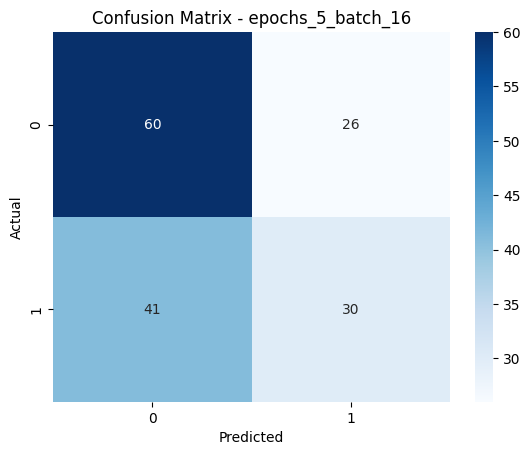

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


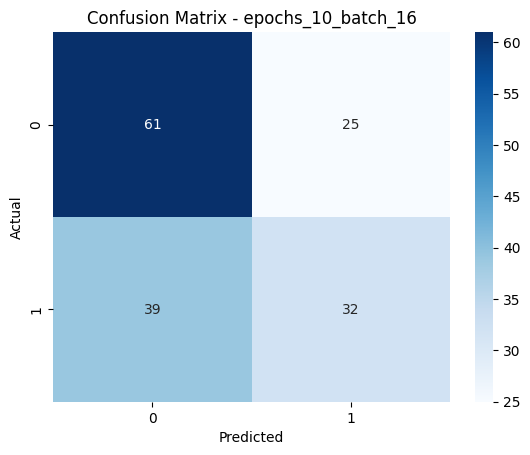

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


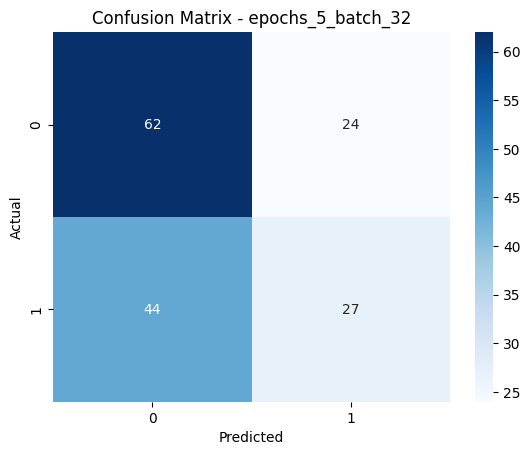

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


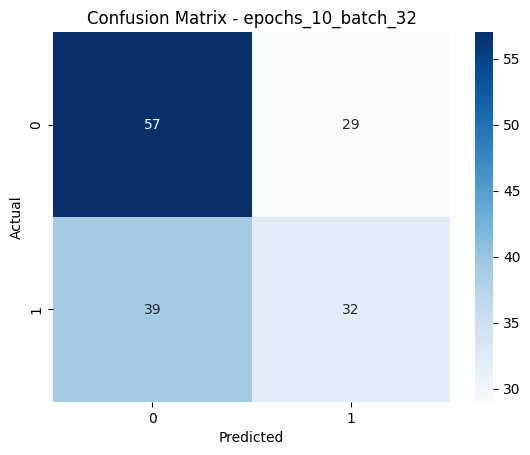

In [25]:
from sklearn.metrics import confusion_matrix

for key, model in trained_models.items():

    y_pred_proba = model.predict(X_test)
    y_pred_classes = (y_pred_proba > 0.5).astype(int)

    cm = confusion_matrix(y_test, y_pred_classes)

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {key}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()